In [1]:
import pandas as pd
import numpy as np

# Load data
df1 = pd.read_csv(r'C:\Users\HP\Downloads\Water_body_datasets 3\rivers_python_cleaned.csv')
df2 = pd.read_csv(r'C:\Users\HP\Downloads\Water_body_datasets 3\medium_minor_rivers_fl.csv')
df3 = pd.read_csv(r'C:\Users\HP\Downloads\Water_body_datasets 3\lakes_ponds_tanks_fl.csv')
df4 = pd.read_csv(r'C:\Users\HP\Downloads\Water_body_datasets 3\ground_water_fl.csv')
df5 = pd.read_csv(r'C:\Users\HP\Downloads\Water_body_datasets 3\canals_seawater_drains_fl.csv')

In [2]:
#Function to unify columns
def process_common(df, temp_min, temp_max, do_min, do_max,
                   ph_min, ph_max, cond_min, cond_max,
                   bod_min, bod_max,
                   nitrate_min, nitrate_max,
                   fc_min, 
                    fc_max, tc_min, tc_max, label):

    new_df = pd.DataFrame()

    new_df['temp'] = df[[temp_min, temp_max]].mean(axis=1)
    new_df['DO'] = df[[do_min, do_max]].mean(axis=1)
    new_df['pH'] = df[[ph_min, ph_max]].mean(axis=1)
    new_df['BOD'] = df[[bod_min, bod_max]].mean(axis=1)
    new_df['nitrate'] = df[[nitrate_min, nitrate_max]].mean(axis=1)

    new_df['faecal_coliform'] = df[fc_max]
    new_df['total_coliform'] = df[tc_max]

    new_df['water_type'] = label

    return new_df

In [3]:
df1.columns = df1.columns.str.strip()

In [4]:
river = process_common(
    df1,
    'Minimum temperature',
    'Maximum temperature',
    'Minimum dissolved oxygen',
    'Maximum dissolved oxygen',
    'Minimum Ph',
    'Maximum Ph',
    'Minimum conductivity',
    'Maximum conductivity',
    'Minimum BOD',
    'Maximum BOD',
    'Minimum nitrates required',
    'Maximum nitrates required',
    'Minimum of faecal coliforms',
    'Maximum of faecal coliforms',
    'Minimum of total coliforms',
    'Maximum of total coliforms',
    'river'
)

In [5]:
df2.columns = df2.columns.str.strip()

In [6]:
minor = process_common(
    df2,
    'Minimum temperature',
    'Maximum temperature',
    'Minimum dissolved oxygen',
    'Maximum dissolved oxygen',
    'Minimum Ph',
    'Maximum Ph',
    'Minimum conductivity',
    'Maximum conductivity',
    'Minimum BOD',
    'Maximum BOD',
    'Minimum nitrates required',
    'Maximum nitrates required',
    'Minimum of faecal coliforms',
    'Maximum of faecal coliforms',
    'Minimum of total coliforms',
    'Maximum of total coliforms',
    'minor'
)

In [7]:
df3.columns = df3.columns.str.strip()

In [8]:
lake = process_common(
    df3,
    'Minimum temperature',
    'Maximum temperature',
    'Minimum dissolved oxygen',
    'Maximum dissolved oxygen',
    'Minimum Ph',
    'Maximum Ph',
    'Minimum conductivity',
    'Maximum conductivity',
    'Minimum BOD',
    'Maximum BOD',
    'Minimum nitrates required',
    'Maximum nitrates required',
    'Minimum of faecal coliforms',
    'Maximum of faecal coliforms',
    'Minimum of total coliforms',
    'Maximum of total coliforms',
    'lake'
)

In [9]:
df4.columns = df4.columns.str.strip()

In [10]:
ground = process_common(
    df4,
    'Minimum temperature',
    'Maximum temperature',
    'Minimum dissolved oxygen',
    'Maximum dissolved oxygen',
    'Minimum Ph',
    'Maximum Ph',
    'Minimum conductivity',
    'Maximum conductivity',
    'Minimum BOD',
    'Maximum BOD',
    'Minimum nitrates required',
    'Maximum nitrates required',
    'Minimum of faecal coliforms',
    'Maximum of faecal coliforms',
    'Minimum of total coliforms',
    'Maximum of total coliforms',
    'ground'
)

In [11]:
df5.columns = df5.columns.str.strip()

In [12]:
canal = process_common(
    df5,
    'Minimum temperature',
    'Maximum temperature',
    'Minimum dissolved oxygen',
    'Maximum dissolved oxygen',
    'Minimum Ph',
    'Maximum Ph',
    'Minimum conductivity',
    'Maximum conductivity',
    'Minimum BOD',
    'Maximum BOD',
    'Minimum nitrates required',
    'Maximum nitrates required',
    'Minimum of faecal coliforms',
    'Maximum of faecal coliforms',
    'Minimum of total coliforms',
    'Maximum of total coliforms',
    'canal'
)

In [13]:
data = pd.concat([river, minor, lake, ground, canal], ignore_index=True)

In [14]:
#water quality index
data['WQI'] = (
    0.25*(1/data['DO']) +
    0.25*(data['BOD']) +
    0.20*(data['nitrate']) +
    0.15*(data['faecal_coliform']) +
    0.15*(data['total_coliform'])
)

In [15]:
y = data['WQI']
data['polluted'] = (data['WQI'] > 100).astype(int)
y = data['polluted']

In [16]:
#test train split first
from sklearn.model_selection import train_test_split

features = ['temp', 'DO', 'pH', 'BOD', 'nitrate', 'faecal_coliform', 'total_coliform']
X = data[features]
y = data['polluted']   # or WQI depending task

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [17]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [18]:
#preprococessing only on train
# Normalize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
#KMeans (fit only on train)
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_train_scaled)

train_clusters = kmeans.predict(X_train_scaled)
test_clusters = kmeans.predict(X_test_scaled)


In [20]:
#corrected
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

# fit only on training data
kmeans.fit(X_train_scaled)

# assign clusters separately
train_clusters = kmeans.predict(X_train_scaled)
test_clusters = kmeans.predict(X_test_scaled)

In [21]:
#corrected
import pandas as pd

# attach cluster labels to training data only
train_cluster_df = X_train.copy()
train_cluster_df['cluster'] = train_clusters

# cluster-wise feature means
print(train_cluster_df.groupby('cluster')[features].mean())

              temp       DO           pH        BOD       nitrate  \
cluster                                                             
0        25.197303  6.46064     8.055577   7.518581      3.339232   
1        28.000000  7.32500  2245.000000   8.252500  81775.000000   
2        26.000000  2.40000     7.850000  34.333333      1.100000   

         faecal_coliform  total_coliform  
cluster                                   
0           2.088764e+06    1.257327e+06  
1           3.500000e+05    5.800000e+02  
2           2.000000e+10    2.000000e+10  


In [22]:
test_cluster_df = X_test.copy()
test_cluster_df['cluster'] = test_clusters

print(test_cluster_df.groupby('cluster')[features].mean())

              temp        DO        pH        BOD   nitrate  faecal_coliform  \
cluster                                                                        
0        25.142386  6.497756  7.570255   7.088649  2.853035     5.168059e+05   
2        27.000000  3.400000  8.000000  91.950000  6.000000     3.500000e+09   

         total_coliform  
cluster                  
0          1.710635e+06  
2          1.600000e+10  


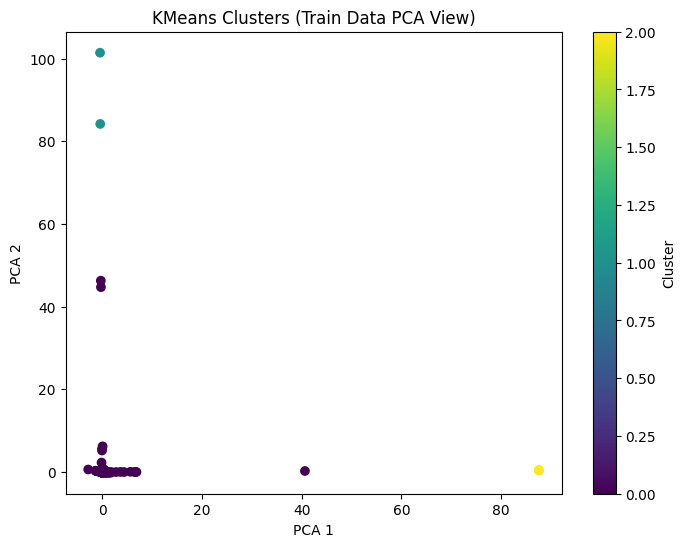

In [23]:
#corrected
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce TRAIN data to 2D (same data used for KMeans training)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=train_clusters, cmap='viridis')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('KMeans Clusters (Train Data PCA View)')
plt.colorbar(label='Cluster')
plt.show()

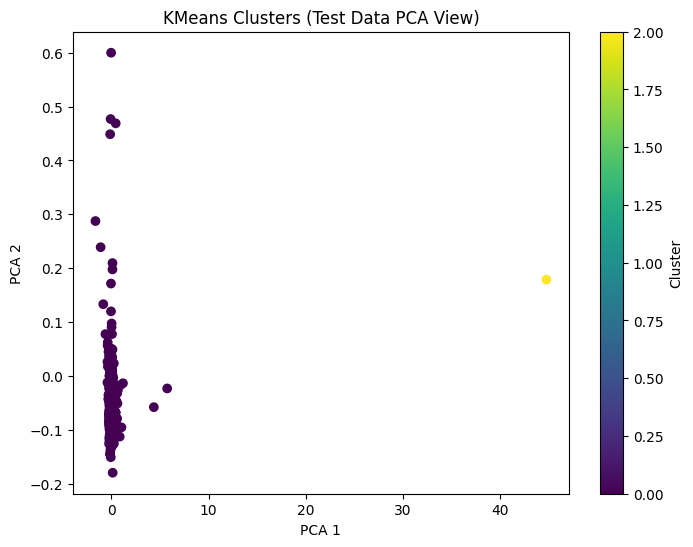

In [24]:
# Transform test data using SAME PCA
X_test_pca = pca.transform(X_test_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=test_clusters, cmap='viridis')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('KMeans Clusters (Test Data PCA View)')
plt.colorbar(label='Cluster')
plt.show()

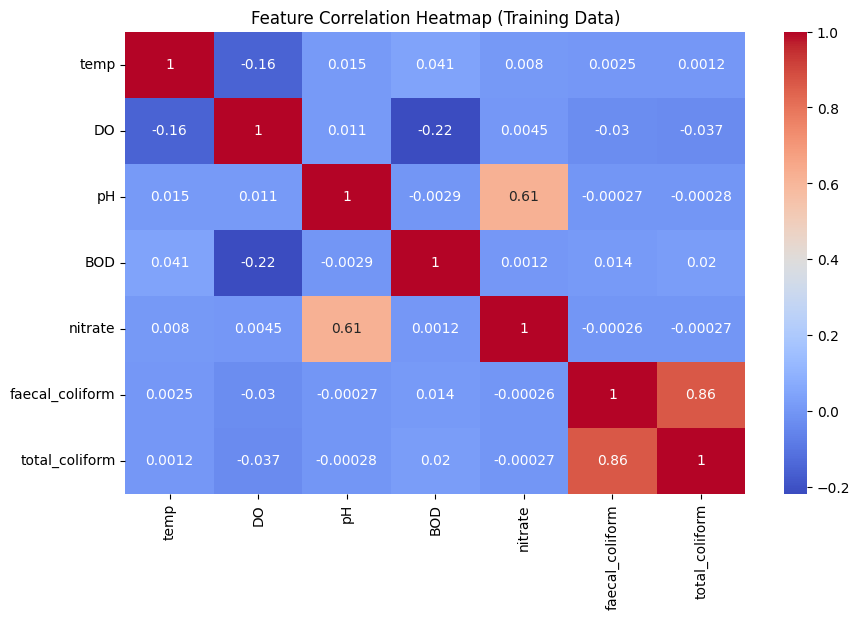

In [25]:
#corrected heat map
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(X_train.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap (Training Data)")
plt.show()

In [26]:
#Isolation Forest (correct usage)
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_train_scaled)

train_anomaly = iso.predict(X_train_scaled)
test_anomaly = iso.predict(X_test_scaled)

In [27]:
#CLASSIFICATION (Polluted vs Safe)
#create label
data['polluted'] = np.where(
    (data['BOD'] > 2) |
    (data['DO'] < 5) |
    (data['faecal_coliform'] > 0),
    1, 0
)

In [28]:
#classification correct
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

clf = RandomForestClassifier()

clf.fit(X_train_scaled, y_train)

pred = clf.predict(X_test_scaled)

y_pred = clf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.984776119402985
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2117
           1       0.99      0.97      0.98      1233

    accuracy                           0.98      3350
   macro avg       0.99      0.98      0.98      3350
weighted avg       0.98      0.98      0.98      3350



In [29]:
#dl corrected 
#corrected 2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_scaled, y_test)
)

C:\Users\HP\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
419/419 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6858 - loss: 0.5974 - val_accuracy: 0.7069 - val_loss: 0.5731
Epoch 2/20
419/419 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7175 - loss: 0.5477 - val_accuracy: 0.7167 - val_loss: 0.5432
Epoch 3/20
419/419 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7262 - loss: 0.5269 - val_accuracy: 0.7233 - val_loss: 0.5302
Epoch 4/20
419/419 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7328 - loss: 0.5141 - val_accuracy: 0.7316 - val_loss: 0.5186
Epoch 5/20
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7376 - loss: 0.5044 - val_accuracy: 0.7322 - val_loss: 0.5156
Epoch 6/20
419/419 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7409 - loss: 0.4983 - val_accuracy: 0.7328 - val_loss: 0.5068
Epoch 7/20
419/419 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7409 - loss: 0.4942 - val_accuracy: 0.7385 - val_loss: 0.5034
Epoch 8/20
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7401 - loss: 0.4899 - val_accuracy: 0.

In [30]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)

print("Test Accuracy:", accuracy)

105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7382 - loss: 0.4748
Test Accuracy: 0.7382089495658875
